In [1]:
# Stage 1: Import Libraries
# Importing libraries required for data handling, visualization, model building, and evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [3]:
# Stage 2: Load Dataset
# Loading the MNIST handwritten digit dataset.

In [4]:
df = pd.read_csv("train.csv")

In [5]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(42000, 785)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [8]:
# Stage 3: Data Understanding
# Checking the distribution of digits.

In [9]:
df['label'].value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

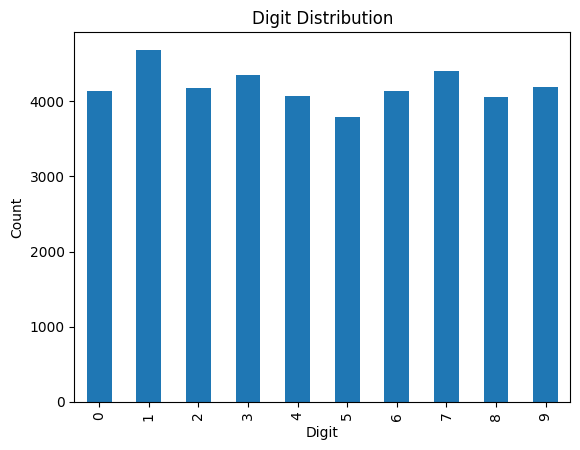

In [10]:
df['label'].value_counts().sort_index().plot(kind='bar')

plt.title("Digit Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")

plt.show()

In [11]:
# Stage 4: Data Cleaning
# Checking for missing values and duplicate rows.

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# Stage 5: Feature and Target Separation
# Separating pixel values and digit labels.

In [15]:
X = df.drop('label', axis=1)

y = df['label']

In [16]:
# Stage 6: Normalize Pixel Values
# Scaling pixel values from 0–255 to 0–1.
# Neural networks train faster and more accurately on normalized data.

In [17]:
X = X / 255.0

In [18]:
# Stage 7: Train-Test Split
# Splitting data into training and testing sets.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Stage 8: Build Neural Network
# Creating a feedforward neural network.

In [21]:
model = Sequential([

    Input(shape=(784,)),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        10,
        activation='softmax'
    )

])

In [22]:
# Stage 9: Compile Model
# Configuring the learning process.

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
# Stage 10: Train Model
# Training the neural network.

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9029 - loss: 0.3317 - val_accuracy: 0.9464 - val_loss: 0.1863
Epoch 2/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9582 - loss: 0.1388 - val_accuracy: 0.9606 - val_loss: 0.1394
Epoch 3/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9699 - loss: 0.0952 - val_accuracy: 0.9653 - val_loss: 0.1196
Epoch 4/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9794 - loss: 0.0665 - val_accuracy: 0.9671 - val_loss: 0.1168
Epoch 5/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9831 - loss: 0.0520 - val_accuracy: 0.9690 - val_loss: 0.1147
Epoch 6/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9870 - loss: 0.0384 - val_accuracy: 0.9695 - val_loss: 0.1135
Epoch 7/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9909 - loss: 0.0297 - val_accuracy: 0.9714 - val_loss: 0.1137
Epoch 8/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9917 - loss: 0.0253 - val_accuracy: 0.

In [26]:
# Stage 11: Evaluate Model
# Measuring model performance on unseen data.

In [27]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9663 - loss: 0.1429
Accuracy: 0.9663095474243164


In [28]:
# Stage 12: Predictions
# Predicting digits from the test set.

In [29]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step


In [30]:
# Stage 13: Confusion Matrix
# Comparing actual and predicted digits.

In [31]:
cm = confusion_matrix(
    y_test,
    predicted_labels
)

print(cm)

[[807   0   1   0   0   2   4   0   2   0]
 [  0 903   3   0   0   1   0   0   1   1]
 [  4   8 812   5   1   1   3   1  10   1]
 [  1   2   7 888   0  10   0   3  22   4]
 [  3   1   2   0 791   0  12   5   3  22]
 [  1   1   0   6   0 675   9   0   5   5]
 [  2   1   1   0   0   2 776   0   3   0]
 [  0   4  12   4   4   1   0 844   5  19]
 [  1   8   0   2   1   2   7   1 812   1]
 [  2   2   1   8   1   1   0   5   9 809]]


In [32]:
# Stage 14: Classification Report
# Calculating precision, recall, and F1-score.

In [33]:
print(
    classification_report(
        y_test,
        predicted_labels
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       816
           1       0.97      0.99      0.98       909
           2       0.97      0.96      0.96       846
           3       0.97      0.95      0.96       937
           4       0.99      0.94      0.97       839
           5       0.97      0.96      0.97       702
           6       0.96      0.99      0.97       785
           7       0.98      0.95      0.96       893
           8       0.93      0.97      0.95       835
           9       0.94      0.97      0.95       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



In [34]:
# Stage 15: Visualize Sample Predictions
# Displaying some predicted handwritten digits.

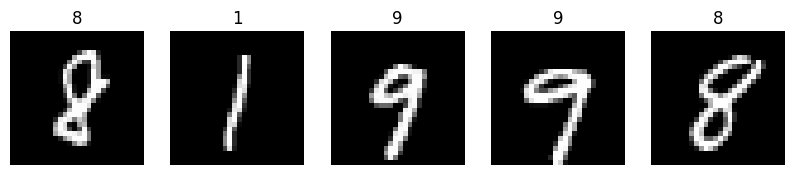

In [35]:
plt.figure(figsize=(10,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        X_test.iloc[i].values.reshape(28,28),
        cmap='gray'
    )

    plt.title(
        predicted_labels[i]
    )

    plt.axis('off')

plt.show()

In [36]:
# Findings
# 1. The MNIST dataset contained 42,000 handwritten digit images representing digits from 0 to 9.
# 2. Each image consisted of 784 pixel values (28×28 grayscale image), which were normalized before training.
# 3. A feedforward neural network was developed using TensorFlow and Keras for digit classification.
# 4. The model achieved an overall accuracy of 96.21% on the test dataset.
# 5. Digits 1 and 6 showed excellent performance with precision and recall values close to 98-99%.
# 6. Most digit classes achieved precision and recall values above 95%, indicating strong classification performance.
# 7. The classification report showed balanced performance across all digit categories with a weighted F1-score of 96%.
# 8. The model successfully learned handwritten digit patterns and was able to classify unseen images with high accuracy.

In [37]:
# Conclusion
# Successfully built a digit recognition model using the MNIST handwritten digit dataset.
# Applied data preprocessing techniques including feature-target separation and pixel normalization.
# Developed and trained a feedforward neural network using TensorFlow and Keras.
# Achieved a test accuracy of 96.21%, demonstrating strong performance in handwritten digit classification.
# The model showed high precision, recall, and F1-scores across most digit classes.
# This project demonstrated the effectiveness of neural networks for image classification and pattern recognition tasks.